In [7]:
Title : COVID-19 Disease Forecasting using Time-Series and Mobility Data

Objective : Analyze COVID-19 trends in India and build forecasting models using time-series and mobility data.

Workflow:
- Data preprocessing
- Feature engineering
- EDA
- Modeling (baseline → improved → mobility → lagged mobility)
- Evaluation & conclusions

In [ ]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [9]:
# loading covid dataset
covid=pd.read_csv('covid_19_data.csv')
print("Dataset shape:",covid.shape)


Dataset shape: (289, 1147)


## DATA UNDERSTANDING

In [10]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


Observation:
Dataset is in wide format (individual dates are columns)
Not suitable for time-series modeling

Action:
We will convert dataset into long format 

## DATA TRANSFORMATION

In [11]:
# converting wide->Long format

covid = covid.melt(
    id_vars=['Province/State','Country/Region','Lat','Long'],
    var_name='date',
    value_name='cases'
)

covid['date'] = pd.to_datetime(covid['date'], format='%m/%d/%y')



we are converting wide to long format because time series analysis requires date as a column (not multiple columns)

In [12]:
# filter india data
india = covid[covid['Country/Region'] == 'India'].copy()

## CLEANING DATA

In [13]:
# Drop unnecessary column which contains all NaN values
india = india.drop(columns=['Province/State'])

# Sort by date for proper time-series analysis
india = india.sort_values('date')

# Select relevant columns which are relevant for our analysis
india_df = india[['date', 'cases']].copy()



Assumption:
The dataset contains cumulative cases.

Reason:
We can observe that the number of cases are increasing on a daily basis and there are no proper fluctuation in the number of
cases and also the difference in number of cases between two consecutives days is also very small.

Action:
We will Convert cumulative → daily cases

In [15]:
# creating daily cases data
india_df['prev_cases'] = india_df['cases'].shift(1)

india_df['daily_cases'] = india_df['cases'] - india_df['prev_cases']

india_df = india_df.dropna()



Insight:
- Daily cases are derived using differencing
- Small negative values (if any) may be present due to very little corrections or fluctuations.

## FEATURE ENGINEERING: LAG FEATURE

In [16]:
india_df['prev_day_cases'] = india_df['daily_cases'].shift(1)

india_df = india_df.dropna()

we are assuming that today's cases may depend on previous day cases trend and hence for proper forecasting we are creating lag feature

## EDA (TIME SERIES ANALYSIS)

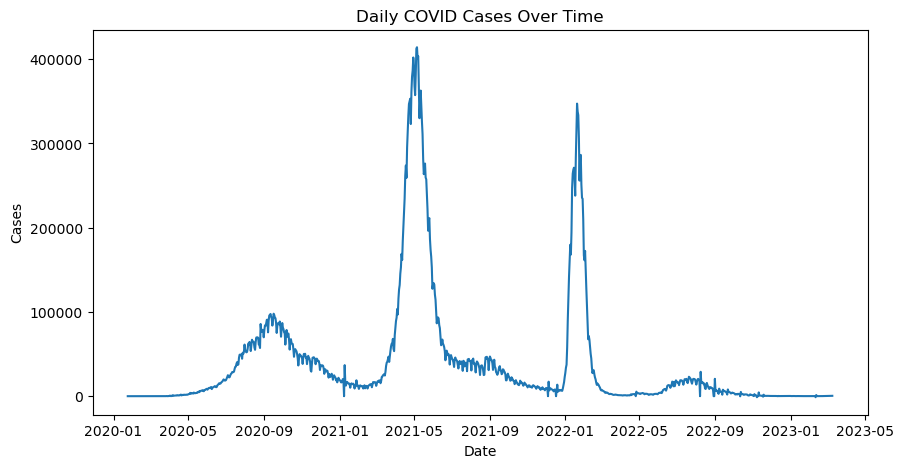

In [17]:
plt.figure(figsize=(10,5))
plt.plot(india_df['date'], india_df['daily_cases'])
plt.title("Daily COVID Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

Inference from the plot :-

The time-series plot of daily COVID-19 cases exhibits clear wave-like patterns, where cases rise rapidly, reach a peak,
and then decline.The largest spike is observed around May 2021, with another significant surge in early 2022.

In addition to these large-scale trends,the data shows high day-to-day variability,as evidenced by the zig-zag pattern
in the curve.This indicates that daily case counts fluctuate significantly and are not stable over short periods.

After late 2022,the number of cases stabilizes at relatively low levels with minimal fluctuations.

From a modeling perspective,this high volatility and presence of sharp spikes make prediction challenging.

## BASELINE MODEL (LAG FEATURE)

In [18]:
# making a baseline model on the basis of lag feature
X = india_df[['prev_day_cases']]
y = india_df['daily_cases']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 1280.8261191569613
RMSE: 3291.422960157178


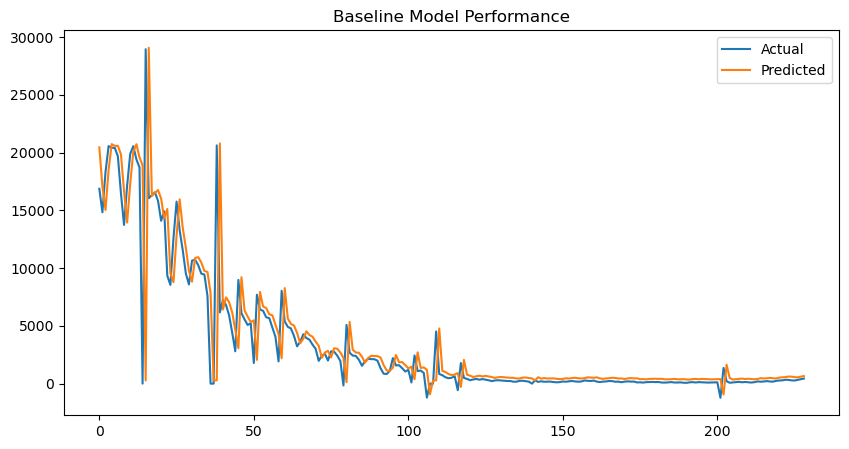

In [19]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Baseline Model Performance")
plt.show()

The model is able to capture the overall trend in daily COVID-19 cases,as the predicted values generally follow the direction of the actual values.However, it struggles to accurately capture sudden spikes and sharp fluctuations in the data.This is because the model relies only on the previous day's cases as a predictor, which limits its ability to respond to abrupt changes.As a result, the model performs well for smooth trends but is less effective during volatile periods.
The limitation arises due to using a single lag feature.
Incorporating additional features such as rolling averages or external data may improve performance.

## FEATURE ENGINEERING: ROLLING FEATURES

In [20]:
# Daily COVID cases are highly volatile and noisy.

# To reduce noise and capture trends properly we introduce:
# 3-day rolling average (for short-term trend)
# 7-day rolling average (for weekly trend)

# ASSUMPTION:
# Recent past trends influence current case counts.

india_df['rolling_mean_3_days'] = india_df['daily_cases'].rolling(3).mean()
india_df['rolling_mean_7_days'] = india_df['daily_cases'].rolling(7).mean()

india_df = india_df.dropna()



## EDA (ROLLING MEAN VS DATE)

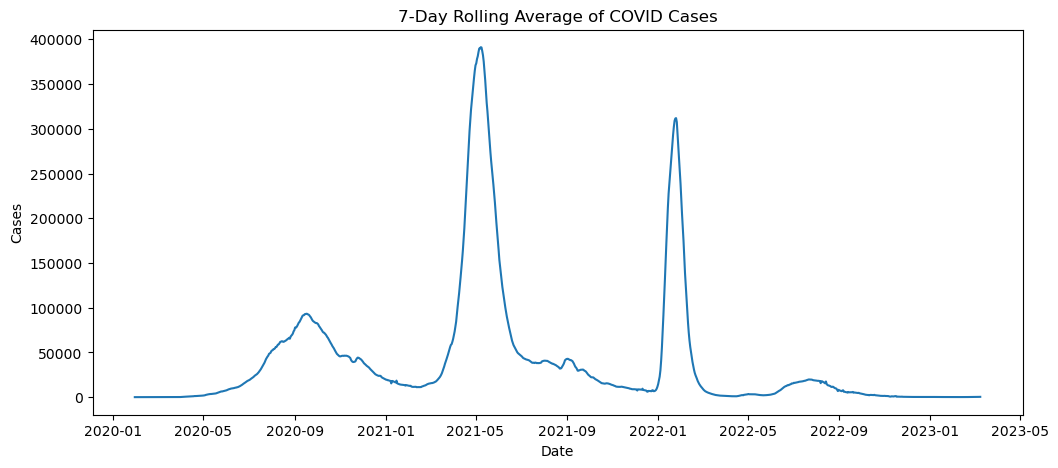

In [21]:
plt.figure(figsize=(12,5))
plt.plot(india_df['date'], india_df['rolling_mean_7_days'])
plt.title("7-Day Rolling Average of COVID Cases")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

Compared to the raw daily case counts, the rolling mean curve is significantly smoother and less volatile, as it
reduces short-term fluctuations and noise in the data. This smoothing effect highlights the underlying trend more clearly.
Since the rolling mean captures the overall trend while minimizing noise, it will allow the model to learn trend in
the data more effectively.

## IMPROVED MODEL (ROLLING FEATURE)

In [22]:
# now we will give previous day covid data as well as 3 day rolling average and 7 day rolling average as input to our model
# Our goal is to improve model by helping the model capture both recent value and trend

X = india_df[['prev_day_cases','rolling_mean_3_days','rolling_mean_7_days']]
y = india_df['daily_cases']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 837.1299805704195
RMSE: 1723.9002783900464


INTERPRETATION :-

- Error reduces compared to baseline model
- Model becomes more stable

INFERENCE :-
- Adding trend-based features significantly improves prediction accuracy

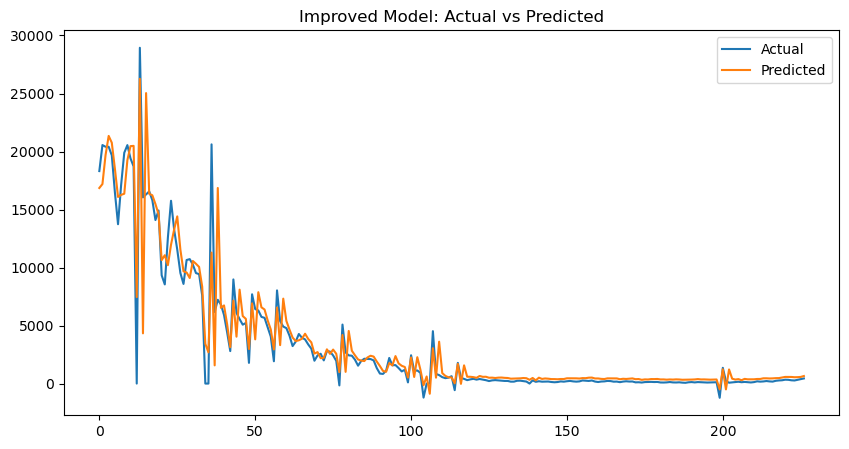

In [23]:
# visualization of improved model

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Improved Model: Actual vs Predicted")
plt.show()

INSIGHT :-

- Predictions follow actual trend more closely compared to baseline model
- Still struggles with sudden spikes

REASON :-
Linear model cannot capture abrupt non-linear changes effectively.

## KDE PLOT (DISTRIBUTION ANALYSIS)

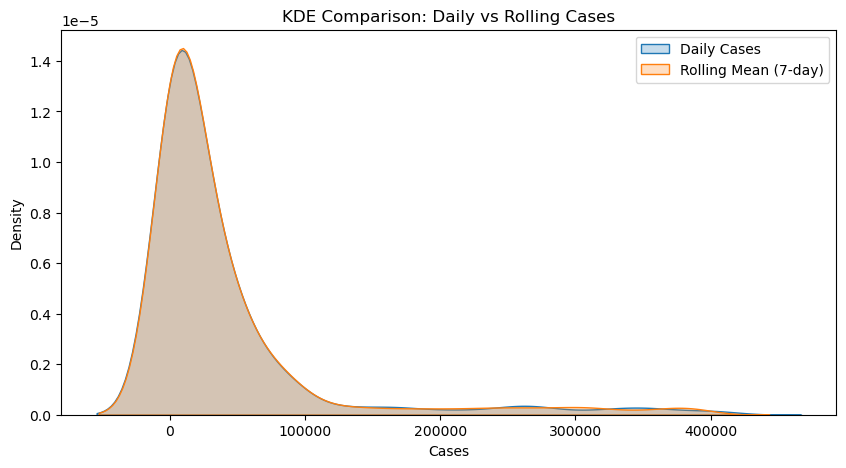

In [24]:
plt.figure(figsize=(10,5))

sns.kdeplot(india_df["daily_cases"], label="Daily Cases", fill=True)
sns.kdeplot(india_df["rolling_mean_7_days"], label="Rolling Mean (7-day)", fill=True)

plt.legend()
plt.title("KDE Comparison: Daily vs Rolling Cases")
plt.xlabel("Cases")
plt.show()

The KDE plots indicate that both daily case counts and rolling mean values are highly right-skewed.The majority of
observations are concentrated in the lower range of case counts, while a small number of days exhibit extremely high
values, forming a long right tail in the distribution.

The rolling mean distribution appears more concentrated compared to daily cases, as smoothing reduces the impact of extreme fluctuations.

This characteristic of the data further explains why modeling daily cases is challenging, as the presence of rare but
extreme spikes makes accurate prediction difficult, especially for simple models.

## EXTERNAL DATA INTEGRATION (MOBILITY DATA)

EXTERNAL DATA INTEGRATION : MOBILITY DATA

RATIONALE:

COVID-19 is an infectious disease that spreads through human interaction.Therefore, human mobility patterns are expected to influence covid transmission.

HYPOTHESIS:

1. Increased mobility (retail, workplaces,transit) → higher COVID cases
2. Increased residential stay → lower COVID cases

GOAL:
To test whether mobility patterns can:
- Explain variation in COVID cases
- Improve forecasting performance

APPROACH:
- Integrate Google Mobility Data with COVID data
- Perform correlation analysis
- Include mobility features in prediction model

In [25]:
# loading mobility data
mobility = pd.read_csv('timep.csv')

print("Shape:", mobility.shape)
mobility.head()


Shape: (212855, 15)


,country_region_code,country_region,sub_region_1,sub_region_2,metro_area,iso_3166_2_code,census_fips_code,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
0,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,15-02-2020,1.0,2.0,3.0,3.0,5.0,0.0
1,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,16-02-2020,2.0,2.0,3.0,2.0,0.0,0.0
2,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,17-02-2020,-1.0,1.0,3.0,1.0,4.0,0.0
3,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,18-02-2020,0.0,2.0,4.0,2.0,3.0,0.0
4,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,19-02-2020,0.0,2.0,1.0,1.0,4.0,1.0


In [26]:
# data understanding
mobility.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212855 entries, 0 to 212854
Data columns (total 15 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   country_region_code                                 212855 non-null  object 
 1   country_region                                      212855 non-null  object 
 2   sub_region_1                                        212534 non-null  object 
 3   sub_region_2                                        201006 non-null  object 
 4   metro_area                                          0 non-null       float64
 5   iso_3166_2_code                                     11528 non-null   object 
 6   census_fips_code                                    0 non-null       float64
 7   place_id                                            212213 non-null  object 
 8   date                                                212855 non-n

OBSERVATION :-

- Contains multiple regions (country + sub-regions)
- Includes multiple mobility categories:
    - Retail & Recreation
    - Grocery & Pharmacy
    - Parks
    - Transit Stations
    - Workplaces
    - Residential

ISSUE :-

We only need national-level data for India and hence we can eliminate data in which it is subdivided into regions.

## DATA CLEANING (MOBILITY DATA)

In [27]:
# Convert date
mobility['date'] = pd.to_datetime(mobility['date'], dayfirst=True)

# Filter only India national-level data
mobility_india = mobility[mobility['sub_region_1'].isna()].copy()

In [ ]:
# REASON:

# - sub_region_1 = NaN represents country-level data
# - Ensures consistency with COVID dataset (national level)

In [28]:
# selecting relevant features
mobility_india = mobility_india[[
    'date',
    'retail_and_recreation_percent_change_from_baseline',
    'grocery_and_pharmacy_percent_change_from_baseline',
    'parks_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'workplaces_percent_change_from_baseline',
    'residential_percent_change_from_baseline'
]]

WHY THESE FEATURES?

Each feature represents a type of human movement:
 - Retail → social interaction
 - Workplaces → daily exposure
 - Transit → travel intensity
 - Residential → staying home

These directly relate to disease spread behavior

In [29]:
# checking data quality
print("Duplicate dates:", mobility_india['date'].duplicated().sum())
print("Shape:", mobility_india.shape)

Duplicate dates: 0
Shape: (321, 7)


In [30]:
# merging with covid data
merged_df = pd.merge(india_df, mobility_india, on='date', how='inner')

print("Merged Shape:", merged_df.shape)
merged_df.head()

Merged Shape: (321, 13)


,date,cases,prev_cases,daily_cases,prev_day_cases,rolling_mean_3_days,rolling_mean_7_days,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
0,2020-02-15,3,3.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,3.0,5.0,0.0
1,2020-02-16,3,3.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,2.0,0.0,0.0
2,2020-02-17,3,3.0,0.0,0.0,0.0,0.0,-1.0,1.0,3.0,1.0,4.0,0.0
3,2020-02-18,3,3.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,2.0,3.0,0.0
4,2020-02-19,3,3.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,4.0,1.0


## CORRELATION ANALYSIS

In [31]:
cols = [
'daily_cases',
'retail_and_recreation_percent_change_from_baseline',
'grocery_and_pharmacy_percent_change_from_baseline',
'parks_percent_change_from_baseline',
'transit_stations_percent_change_from_baseline',
'workplaces_percent_change_from_baseline',
'residential_percent_change_from_baseline'
]

corr_matrix = merged_df[cols].corr()

corr_matrix['daily_cases']

daily_cases                                           1.000000
retail_and_recreation_percent_change_from_baseline    0.177521
grocery_and_pharmacy_percent_change_from_baseline     0.384676
parks_percent_change_from_baseline                   -0.181532
transit_stations_percent_change_from_baseline         0.203020
workplaces_percent_change_from_baseline               0.213566
residential_percent_change_from_baseline             -0.211995
Name: daily_cases, dtype: float64

INTERPRETATION:

Positive Correlation
 - Retail,grocery,transit,workplace mobility → increase in cases
 - More movement → more contact → higher transmission

Negative Correlation
 - Residential mobility → decrease in cases
 - Staying at home reduces spread

Weak Correlation
 - Parks → minimal effect
 - Open spaces may have lower transmission risk

INFERENCE:

- Mobility patterns are related to disease spread, but correlation is moderate to low (not very strong)

## MODEL WITH MOBILITY FEATURES

In [32]:
features = [
'prev_day_cases',
'rolling_mean_3_days',
'rolling_mean_7_days',
'retail_and_recreation_percent_change_from_baseline',
'grocery_and_pharmacy_percent_change_from_baseline',
'parks_percent_change_from_baseline',
'transit_stations_percent_change_from_baseline',
'workplaces_percent_change_from_baseline',
'residential_percent_change_from_baseline'
]

X = merged_df[features].fillna(0)
y = merged_df['daily_cases']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 2062.1248475479397
RMSE: 2754.0941881818508


Model performance worsened compared to previous model.

REASON :-

1. Mobility impact is not immediate (Infection → incubation → testing → reporting delay)

2. Linear regression cannot capture complex relationships

3. Mobility features may introduce noise without proper alignment

KEY INSIGHT :-

Mobility affects COVID spread,but its impact is delayed and indirect.



Next step we can do 'LAGGED MOBILITY ANALYSIS'

HYPOTHESIS:

Mobility does not impact cases instantly.

Instead:
- Increased movement today → infections after few days
- Cases reported after incubation period (~5–10 days)

ASSUMPTION :-

Mobility features with time lag (e.g., 7 days) may better explain covid case variation.

APPROACH :-

Create 7-day lag features for all mobility variables

In [33]:
mobility_cols = [
'retail_and_recreation_percent_change_from_baseline',
'grocery_and_pharmacy_percent_change_from_baseline',
'parks_percent_change_from_baseline',
'transit_stations_percent_change_from_baseline',
'workplaces_percent_change_from_baseline',
'residential_percent_change_from_baseline'
]

for col in mobility_cols:
    merged_df[col + "_lag_7"] = merged_df[col].shift(7)


merged_df_lag = merged_df.dropna().copy()

## MODEL WITH LAGGED MOBILITY

In [34]:
features = [
'prev_day_cases',
'rolling_mean_3_days',
'rolling_mean_7_days'
] + [col + "_lag_7" for col in mobility_cols]

X = merged_df_lag[features]
y = merged_df_lag['daily_cases']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 2181.2147369006566
RMSE: 2754.9397950931366


FINAL INTERPRETATION OF LAGGED MODEL :-

Model performance still does not improve significantly

REASON :-

Mobility-Covid case relationship is highly complex

Many external factors affect spread:
1.) Government policies
2.) Testing rates
3.) Vaccination
4.) Covid virus Variants

Also Linear regression is too simple for such dynamics

FINAL CONCLUSION:

1. Lag and rolling features improved prediction significantly
2. Rolling averages helped capture trends and reduce noise
3. Mobility data showed correlation but did not improve prediction
4. Lagged mobility also did not help due to complex relationships

LIMITATIONS:
- Linear regression is too simple for real-world data
- Important factors like vaccination and policies are missing

KEY LEARNING:
Feature quality is more important than number of features

FUTURE WORK:
- Use advanced models like ARIMA, Random Forest, LSTM